## HW02: Exploratory Data Analysis (Part 01)

This is Assignment 02 for the course "Introduction to Data Science" at the Faculty of Information Technology, University of Science, Vietnam National University, Ho Chi Minh City.

---

(Latest update: 26/10/2024)

Student Name: Lý Liên Hoa

Student ID: 22127117

---

## **How to Complete and Submit the Assignment**

&#9889; **Note**: You should follow the instructions below. If anything is unclear, you need to contact the teaching assistant or instructor immediately for timely support.

**How to Do the Assignment**

You will work directly on this notebook file. First, fill in your full name and student ID (MSSV) in the header section of the file above. In the file, complete the tasks in sections marked:
```python
# YOUR CODE HERE
raise NotImplementedError()
```
Or for optional code sections:
```python
# YOUR CODE HERE (OPTION)
```
For markdown cells, complete the answer in the section marked:
```markdown
YOUR ANSWER HERE
```

**How to Submit the Assignment**

Before submitting, select `Kernel` -> `Restart Kernel & Run All Cells` if you are using a local environment, or `Runtime -> Restart session` and run all if using Google Colab, to ensure everything works as expected.

Next, create a submission folder with the following structure:
- Folder named `MSSV` (for example, if your student ID is `1234567`, name the folder `1234567`)
    - File `HW02.0.ipynb` (no need to submit other files)

Finally, compress this `MSSV` folder in `.zip` format (not `.rar` or any other format) and submit it via the link on Moodle.\
<font color=red>Please make sure to strictly follow this submission guideline.</font>

---

## Import

In [1]:
import requests
import numpy as np
import pandas as pd
from typing import List

import urllib.robotparser

import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
BASE_URL = 'http://api.worldbank.org/v2/'


INDICATOR_CODES = ['SP.POP.TOTL',
                   'SP.POP.TOTL.FE.IN',
                   'SP.POP.TOTL.MA.IN',
                   'SP.DYN.CBRT.IN',
                   'SP.DYN.CDRT.IN',
                   'SE.COM.DURS',
                   'SL.IND.EMPL.ZS',
                   'SL.AGR.EMPL.ZS',
                   'SL.AGR.EMPL.FE.ZS',
                   'SL.IND.EMPL.FE.ZS',
                   'SL.UEM.TOTL.ZS',
                   'NY.GDP.MKTP.CD',
                   'NY.ADJ.NNTY.PC.KD.ZG',
                   'NY.GSR.NFCY.CD',
                   'NV.AGR.TOTL.CD',
                   'EG.USE.ELEC.KH.PC',
                   'EG.FEC.RNEW.ZS',
                   'EG.USE.COMM.FO.ZS',
                   'SP.DYN.LE00.MA.IN',
                   'SP.DYN.LE00.FE.IN',
                   'SE.PRM.ENRR',
                   'SE.TER.ENRR',
                   'SE.PRM.CMPT.ZS',
                   'SE.ADT.1524.LT.ZS']


features_mapping = {
    "SP.POP.TOTL": "Total Population",
    "SP.POP.TOTL.FE.IN": "Female Population",
    "SP.POP.TOTL.MA.IN": "Male Population",
    "SP.DYN.CBRT.IN": "Birth Rate",
    "SP.DYN.CDRT.IN": "Death Rate",
    "SE.COM.DURS": "Compulsory Education Dur.",
    "SL.IND.EMPL.ZS": "Employment in Industry(%)",
    "SL.AGR.EMPL.ZS": "Employment in Agriculture(%)",
    "SL.AGR.EMPL.FE.ZS": "Female Employment in Agriculture(%)",
    "SL.IND.EMPL.FE.ZS": "Female Employment in Industry(%)",
    "SL.UEM.TOTL.ZS": "Unemployment(%)",
    "NY.GDP.MKTP.CD": "GDP in USD",
    "NY.ADJ.NNTY.PC.KD.ZG": "National Income per Capita",
    "NY.GSR.NFCY.CD": "Net income from Abroad",
    "NV.AGR.TOTL.CD": "Agriculture value added(in USD)",
    "EG.USE.ELEC.KH.PC": "Electric Power Consumption(kWH per capita)",
    "EG.FEC.RNEW.ZS": "Renewable Energy Consumption (%)",
    "EG.USE.COMM.FO.ZS": "Fossil Fuel Consumption (%)",
    "SP.DYN.LE00.MA.IN": "Male life expectancy",
    "SP.DYN.LE00.FE.IN": "Female life expectancy ",
    "SE.PRM.ENRR": "School enrollment, primary",
    "SE.TER.ENRR": "School enrollment, tertiary",
    "SE.PRM.CMPT.ZS": "Primary completion rate",
    "SE.ADT.1524.LT.ZS": "Literacy rate"
}

In [3]:
def loadData(country_code: str, format: str = "json", per_page: int = 100, year_interval: str = '2015:2022') -> List:
    # BẠN ĐIỀU CHỈNH LẠI HÀM CRAWL DỮ LIỆU ĐÃ IMPLEMENT Ở HW1
    # YOUR CODE HERE
    
    data_list = {feature: [] for feature in features_mapping.values()}
    years = []
    
    for indicator_code in INDICATOR_CODES:
        url = f"{BASE_URL}country/{country_code}/indicator/{indicator_code}"
        
        params = {
            "date": year_interval,
            "format": format,
            "per_page": per_page
        }
        
        try:
            response = requests.get(url, params=params)
            
            if response.status_code == 200:
                data = response.json()
                
                if len(data) > 1 and data[1]:
                    records = data[1]
                    
                    for record in records:
                        #country = record['countryiso3code']
                        year = int(record['date'])
                        feature_value = record['value']
                        
                        feature_name = features_mapping[indicator_code]
                        
                        if year not in years:
                            years.append(year)

                        
                        if feature_value is not None:
                            data_list[feature_name].append(float(feature_value))
                        else:
                            data_list[feature_name].append(None)
                            
        except Exception as e:
            print(f"Error: {e}")                    
            
    result = []
    for feature in features_mapping.values():
        result.append(data_list[feature])
    
    result.append(years)
    
    return result

In [4]:
def loadDataCountry(country_code: str, format: str = "json", per_page: int = 100, year_interval: str = '2015:2022', is_display: bool = False) -> pd.DataFrame:
    df_country_code = pd.read_csv("./country-codes.csv")
    df_country_code = df_country_code.fillna("NA")
    COUNTRIES_MAPPING = dict(
        zip(df_country_code["alpha-2-code"], df_country_code["name"]))
    del df_country_code

    col_list = list(features_mapping.values())
    col_list.append('Year')

    print(f"[LOG] Loading data for {COUNTRIES_MAPPING[country_code]}")

    dataLst = loadData(country_code=country_code, format=format,
                       per_page=per_page, year_interval=year_interval)

    df = pd.DataFrame(np.column_stack(dataLst), columns=col_list)

    df['Country'] = COUNTRIES_MAPPING[country_code]

    if is_display:
        from IPython.display import display
        display(df.head())

    return df

In [5]:
def replacer(s, newstring, index, nofail=False):
    if not nofail and index not in range(len(s)):
        raise ValueError("index outside given string")
    if index < 0:  # add it to the beginning
        return newstring + s
    if index > len(s):  # add it to the end
        return s + newstring
    return s[:index] + newstring + s[index + 1:]

In [6]:
def loadDataContinent(continent: str = "Asia", format: str = "json", per_page: int = 100, year_interval: str = '2015:2022', is_display: bool = False) -> pd.DataFrame:
    if continent.lower() not in ['asia', 'europe', 'africa', 'oceania', 'americas']:
        print(
            f"[LOG] Please check input continent again. We don't support {continent}.")
        raise ValueError

    if not continent[0].isupper():
        continent = replacer(continent, continent[0].upper(), 0)

    # Định nghĩa một số country codes
    df_country_code = pd.read_csv("./country-codes.csv")
    df_country_code = df_country_code.fillna("NA")
    df_country_code = df_country_code[df_country_code["continent"] == continent]
    lst_country_codes = df_country_code["alpha-2-code"]
    del df_country_code

    df = pd.DataFrame()
    for country_code in lst_country_codes:
        df = pd.concat([df, loadDataCountry(
            country_code=country_code,
            format=format,
            per_page=per_page,
            year_interval=year_interval,
            is_display=False)], axis=0)

    if is_display:
        from IPython.display import display
        display(df.head())

    return df

In [7]:
def saveDataFrame2CSV(df: pd.DataFrame, save_path: str, sep: str = ',', encoding: str = 'utf-8') -> bool:
    try:
        df.to_csv(save_path, sep=sep, encoding=encoding, index=False)
    except:
        raise ModuleNotFoundError
        # return False
    return True

---

## Data collecting

In [8]:
# YOUR CODE HERE
# Just replace your name, and your student ID number
studentName = "Ly Lien Hoa"
studentID = 22127117

In [9]:
format: str = "json"
per_page: int = 100

# TODO: Define your wanted year interval here, highly recommended from 1995 to 2022 or 1985 to 2022
# YOUR CODE HERE
year_interval: str = "1995:2022"

is_display: bool = True

In [10]:
def continentChooser(studentID: int) -> str:
    return str(['asia', 'europe', 'africa', 'americas'][studentID % 4])
    
your_continent:str = continentChooser(studentID=studentID)
your_continent

'europe'

In [11]:
df = loadDataContinent(
    continent = your_continent,
    format = format,
    per_page = per_page,
    year_interval = year_interval,
    is_display = is_display
)

[LOG] Loading data for Albania
[LOG] Loading data for Austria
[LOG] Loading data for Belarus
[LOG] Loading data for Belgium
[LOG] Loading data for Bosnia and Herzegovina
[LOG] Loading data for Bulgaria
[LOG] Loading data for Croatia
[LOG] Loading data for Czech Republic
[LOG] Loading data for Denmark
[LOG] Loading data for Estonia
[LOG] Loading data for Faroe Islands
[LOG] Loading data for Finland
[LOG] Loading data for France
[LOG] Loading data for Germany
[LOG] Loading data for Gibraltar
[LOG] Loading data for Greece
[LOG] Loading data for Hungary
[LOG] Loading data for Iceland
[LOG] Loading data for Ireland
[LOG] Loading data for Italy
[LOG] Loading data for Latvia
[LOG] Loading data for Liechtenstein
[LOG] Loading data for Lithuania
[LOG] Loading data for Luxembourg
[LOG] Loading data for Macedonia, FYR
[LOG] Loading data for Malta
[LOG] Loading data for Moldova
[LOG] Loading data for Monaco
[LOG] Loading data for Netherlands
[LOG] Loading data for Norway
[LOG] Loading data for Pol

,Total Population,Female Population,Male Population,Birth Rate,Death Rate,Compulsory Education Dur.,Employment in Industry(%),Employment in Agriculture(%),Female Employment in Agriculture(%),Female Employment in Industry(%),...,Renewable Energy Consumption (%),Fossil Fuel Consumption (%),Male life expectancy,Female life expectancy,"School enrollment, primary","School enrollment, tertiary",Primary completion rate,Literacy rate,Year,Country
0,2777689.0,1392115.0,1385573.0,10.116,11.194,9.0,21.400145,34.926718,39.814582,16.770695,...,None,None,74.502,79.472,96.371231,62.647919,101.176277,99.5,2022,Albania
1,2811666.0,1407212.0,1404454.0,10.24,11.325,9.0,21.17753,35.640848,40.852257,16.679231,...,41.9,None,74.087,79.173,97.107498,59.969872,97.218437,None,2021,Albania
2,2837849.0,1418585.0,1419264.0,10.285,10.785,9.0,20.628047,36.190744,41.139849,16.570277,...,44.4,None,74.632,79.676,100.020973,61.5853,99.271927,None,2020,Albania
3,2854191.0,1425364.0,1428828.0,10.343,8.48,9.0,20.150666,36.416856,41.576031,16.196075,...,40.1,None,77.168,81.666,102.589539,61.408508,98.717529,None,2019,Albania
4,2866376.0,1430495.0,1435881.0,10.517,8.308,9.0,19.74566,37.285732,42.247889,15.565411,...,37.8,None,77.037,81.608,104.568024,56.080299,102.89418,None,2018,Albania


In [12]:
# Save raw data to disk
save_name = "_".join([str(studentID), str(your_continent)]) + ".csv"
saveDataFrame2CSV(df, os.path.join("./", save_name))

True

## Exploring your data

### Read raw data from file (0.25 points)

First, declare `raw_df` to store your data when read with Pandas.

In [13]:
# YOUR CODE HERE
raw_df = pd.read_csv('22127117_europe.csv')

In [14]:
# TEST
raw_df.head()

,Total Population,Female Population,Male Population,Birth Rate,Death Rate,Compulsory Education Dur.,Employment in Industry(%),Employment in Agriculture(%),Female Employment in Agriculture(%),Female Employment in Industry(%),...,Renewable Energy Consumption (%),Fossil Fuel Consumption (%),Male life expectancy,Female life expectancy,"School enrollment, primary","School enrollment, tertiary",Primary completion rate,Literacy rate,Year,Country
0,2777689.0,1392115.0,1385573.0,10.116,11.194,9.0,21.400145,34.926718,39.814582,16.770695,...,NaN,NaN,74.502,79.472,96.371231,62.647919,101.176277,99.5,2022,Albania
1,2811666.0,1407212.0,1404454.0,10.240,11.325,9.0,21.177530,35.640848,40.852257,16.679231,...,41.9,NaN,74.087,79.173,97.107498,59.969872,97.218437,NaN,2021,Albania
2,2837849.0,1418585.0,1419264.0,10.285,10.785,9.0,20.628047,36.190744,41.139849,16.570277,...,44.4,NaN,74.632,79.676,100.020973,61.585300,99.271927,NaN,2020,Albania
3,2854191.0,1425364.0,1428828.0,10.343,8.480,9.0,20.150666,36.416856,41.576031,16.196075,...,40.1,NaN,77.168,81.666,102.589539,61.408508,98.717529,NaN,2019,Albania
4,2866376.0,1430495.0,1435881.0,10.517,8.308,9.0,19.745660,37.285732,42.247889,15.565411,...,37.8,NaN,77.037,81.608,104.568024,56.080299,102.894180,NaN,2018,Albania


### How many rows and how many columns does the raw data have? (0.25 points)

Next, you calculate the number of rows and columns of the DataFrame `raw_df` and store it in the variable `shape` (tuple). **If your data has the number of rows smaller than 1000, please crawl the data once again with larger year interval**.

In [15]:
# YOUR CODE HERE
shape = raw_df.shape

In [16]:
# TEST
print(f"Current shape: {shape}")

if shape[0] > 1000:
    print(f"Your data good!.")
else:
    print(f"Your raw data absolutely small. Please choose larger year interval.!")

Current shape: (1120, 26)
Your data good!.


### What does each line mean? Does it matter if the lines have different meanings?

YOUR ANSWER HERE
- Each line in the dataset represents data of a year for a specific European country about general aspects like population, education, employment, energy.

- It matters when lines have different meanings because consistent data structure is important. When data is not consistent, it can lead to errors in analysis and make it hard to compare information.

### Does the raw data have duplicate rows? (0.25 points)

Next, you calculate the number of rows with duplicate indexes and store it in the variable `num_duplicated_rows`. In a group of lines with the same index, the first line is not counted as repeated.

In [17]:
# YOUR CODE HERE
duplicated_rows = raw_df.duplicated()
num_duplicated_rows = duplicated_rows.sum()

In [18]:
# TEST
if num_duplicated_rows == 0:
    print(f"Your raw data have no duplicated line.!")
else:
    if num_duplicated_rows > 1:
        ext = "lines"
    else:
        ext = "line"
    print(f"Your raw data have {num_duplicated_rows} duplicated " + ext + ". Please de-deduplicate your raw data.!")

Your raw data have no duplicated line.!


### What does each column mean? (0.25đ)

To see the meaning of each column:
- First, you need to read the file "assignment_schema.csv" into DataFrame `col_meaning_df`; you also need to make the "Query API" column an index column.
- Then, you just need to display the DataFrame `col_meaning_df` for viewing. You can use `pd.set_option` to customize the table width so that strings that are too long are not truncated.

In [19]:
# YOUR CODE HERE
col_meaning_df = pd.read_csv('assignment_schema.csv')

In [20]:
# TEST
col_meaning_df

,Query API,Meaning
0,SP.POP.TOTL,Total Population
1,SP.POP.TOTL.FE.IN,Female Population
2,SP.POP.TOTL.MA.IN,Male Population
3,SP.DYN.CBRT.IN,Birth Rate
4,SP.DYN.CDRT.IN,Death Rate
5,SE.COM.DURS,Compulsory Education Dur
6,SL.IND.EMPL.ZS,Employment in Industry(%)
7,SL.AGR.EMPL.ZS,Employment in Agriculture(%)
8,SL.AGR.EMPL.FE.ZS,Female Employment in Agriculture(%)
9,SL.IND.EMPL.FE.ZS,Female Employment in Industry(%)


Before moving forward, you should read the results displayed above and make sure you understand the meaning of the columns. To understand the meaning of the column, you may need to look at the values of the DataFrame side column `raw_df`.

### What data type does each column currently have? Are there any columns whose data types are not suitable for further processing? (0.25 points)

Next, you calculate the data type (dtype) of each column in DataFrame `raw_df` and save the result into Series `dtypes` (This Series has the index as the column name).

In [21]:
# YOUR CODE HERE
dtypes = raw_df.dtypes

In [22]:
# TEST
dtypes

Total Population                              float64
Female Population                             float64
Male Population                               float64
Birth Rate                                    float64
Death Rate                                    float64
Compulsory Education Dur.                     float64
Employment in Industry(%)                     float64
Employment in Agriculture(%)                  float64
Female Employment in Agriculture(%)           float64
Female Employment in Industry(%)              float64
Unemployment(%)                               float64
GDP in USD                                    float64
National Income per Capita                    float64
Net income from Abroad                        float64
Agriculture value added(in USD)               float64
Electric Power Consumption(kWH per capita)    float64
Renewable Energy Consumption (%)              float64
Fossil Fuel Consumption (%)                   float64
Male life expectancy        

We observe that the column `Year` has numeric type. However, its magnitude does not have a significance. And, it actually represents a period instead of a number. Thus, it can be convert to categorical type.

In [23]:
# YOUR CODE HERE
raw_df['Year'] = pd.Categorical(raw_df['Year'])
raw_df['Country'] = pd.Categorical(raw_df['Country'])

In [24]:
raw_df.dtypes

Total Population                               float64
Female Population                              float64
Male Population                                float64
Birth Rate                                     float64
Death Rate                                     float64
Compulsory Education Dur.                      float64
Employment in Industry(%)                      float64
Employment in Agriculture(%)                   float64
Female Employment in Agriculture(%)            float64
Female Employment in Industry(%)               float64
Unemployment(%)                                float64
GDP in USD                                     float64
National Income per Capita                     float64
Net income from Abroad                         float64
Agriculture value added(in USD)                float64
Electric Power Consumption(kWH per capita)     float64
Renewable Energy Consumption (%)               float64
Fossil Fuel Consumption (%)                    float64
Male life 

In [25]:
# TEST
dtypes = raw_df.dtypes
float_cols = set(dtypes[(dtypes==np.float32) | (dtypes==np.float64)].index)
assert len(float_cols) == 24
cate_cols = set(dtypes[dtypes == 'category'].index)
assert (len(cate_cols) == 2)

In [26]:
dtypes

Total Population                               float64
Female Population                              float64
Male Population                                float64
Birth Rate                                     float64
Death Rate                                     float64
Compulsory Education Dur.                      float64
Employment in Industry(%)                      float64
Employment in Agriculture(%)                   float64
Female Employment in Agriculture(%)            float64
Female Employment in Industry(%)               float64
Unemployment(%)                                float64
GDP in USD                                     float64
National Income per Capita                     float64
Net income from Abroad                         float64
Agriculture value added(in USD)                float64
Electric Power Consumption(kWH per capita)     float64
Renewable Energy Consumption (%)               float64
Fossil Fuel Consumption (%)                    float64
Male life 

### For each column with numeric data type, how are the values distributed? (1đ)

For columns with numeric data types, you will calculate:
- Percentage (from 0 to 100) of missing values
- The min
- The lower quartile
- The median
- The upper quartile
- The max

You will save the results to a DataFrame `num_col_info_df`, where:
- The names of the columns are the names of the numeric columns in `raw_df`
- Names of rows: "missing_ratio", "min", "lower_quartile", "median", "upper_quartile", "max"  

For ease of viewing, you round all values to 1 decimal place using the `.round(1)` method.

In [27]:
# YOUR CODE HERE
numeric_cols = raw_df.select_dtypes(include=[np.number])

cols_num_missing = numeric_cols.isna().sum()
missing_ratios = cols_num_missing / len(raw_df) * 100

min_values = numeric_cols.min()

lower_quartiles = numeric_cols.quantile(0.25)

medians = numeric_cols.median()

upper_quartiles = numeric_cols.quantile(0.75)

max_values = numeric_cols.max()

dictionary = {
    "missing_ratio": missing_ratios,
    "min": min_values,
    "lower_quartile": lower_quartiles,
    "median": medians,
    "upper_quartile": upper_quartiles,
    "max": max_values
}

num_col_info_df = pd.DataFrame(dictionary).T.round(1)

num_col_info_df

,Total Population,Female Population,Male Population,Birth Rate,Death Rate,Compulsory Education Dur.,Employment in Industry(%),Employment in Agriculture(%),Female Employment in Agriculture(%),Female Employment in Industry(%),...,Agriculture value added(in USD),Electric Power Consumption(kWH per capita),Renewable Energy Consumption (%),Fossil Fuel Consumption (%),Male life expectancy,Female life expectancy,"School enrollment, primary","School enrollment, tertiary",Primary completion rate,Literacy rate
missing_ratio,0.0,0.0,0.0,2.9,2.9,15.0,12.6,12.6,12.6,12.6,...,9.200000e+00,35.7,8.2,34.2,5.0,5.0,12.5,17.9,33.6,93.8
min,24886.0,12779.0,12107.0,5.9,5.5,8.0,9.1,0.7,0.2,3.4,...,2.000451e+05,663.8,0.0,10.3,60.0,67.8,80.0,7.5,70.4,95.7
lower_quartile,1987960.0,1011190.0,963965.0,9.4,8.4,9.0,21.2,3.0,1.7,9.5,...,9.769157e+08,3620.2,6.3,63.3,71.5,78.7,99.1,46.6,96.8,99.0
median,5376421.5,2743866.5,2625597.5,10.4,9.7,10.0,26.3,5.3,3.4,14.1,...,3.327716e+09,5360.7,15.1,79.0,75.4,81.3,101.1,61.4,99.0,100.0
upper_quartile,10529751.2,5423154.8,5164743.0,11.8,11.6,11.0,31.0,12.0,11.1,19.8,...,7.224178e+09,7127.1,27.5,89.0,78.5,83.4,103.9,74.6,100.4,100.0
max,83797985.0,42450429.0,41347556.0,25.0,21.7,13.0,43.1,60.4,63.4,34.8,...,5.318212e+10,54799.2,82.9,100.0,83.1,86.7,151.9,166.7,150.2,100.0


In [28]:
# TEST
assert num_col_info_df["Total Population"]["missing_ratio"] == 0

In [29]:
dict(num_col_info_df.iloc[0])

{'Total Population': 0.0,
 'Female Population': 0.0,
 'Male Population': 0.0,
 'Birth Rate': 2.9,
 'Death Rate': 2.9,
 'Compulsory Education Dur.': 15.0,
 'Employment in Industry(%)': 12.6,
 'Employment in Agriculture(%)': 12.6,
 'Female Employment in Agriculture(%)': 12.6,
 'Female Employment in Industry(%)': 12.6,
 'Unemployment(%)': 12.6,
 'GDP in USD': 2.9,
 'National Income per Capita': 23.2,
 'Net income from Abroad': 14.3,
 'Agriculture value added(in USD)': 9.2,
 'Electric Power Consumption(kWH per capita)': 35.7,
 'Renewable Energy Consumption (%)': 8.2,
 'Fossil Fuel Consumption (%)': 34.2,
 'Male life expectancy': 5.0,
 'Female life expectancy ': 5.0,
 'School enrollment, primary': 12.5,
 'School enrollment, tertiary': 17.9,
 'Primary completion rate': 33.6,
 'Literacy rate': 93.8}

After identifying the basic statistical numbers that describe your data, we further need to determine the features that have a large number of missing values. Such features are not useful for the analysis stage and must be removed from the dataset.

Depending on your goals, the threshold for "large" can be defined. Usually, if the percentage of missing values is greater than 75%, the column is dropped from the dataframe and an updated dataframe is returned.

In [30]:
def drop_missing_features(df: pd.DataFrame, missing_lst: dict = dict(num_col_info_df.iloc[0]), threshold: float = 75.0) -> pd.DataFrame:
    # YOUR CODE HERE
    dropped_columns = [col for col, val in missing_lst.items() if val > threshold]
    
    df_dropped = df.drop(columns=dropped_columns, axis=1)
    return df_dropped

raw_df = drop_missing_features(raw_df, dict(num_col_info_df.iloc[0]))

In [31]:
# TEST
raw_df.head()

,Total Population,Female Population,Male Population,Birth Rate,Death Rate,Compulsory Education Dur.,Employment in Industry(%),Employment in Agriculture(%),Female Employment in Agriculture(%),Female Employment in Industry(%),...,Electric Power Consumption(kWH per capita),Renewable Energy Consumption (%),Fossil Fuel Consumption (%),Male life expectancy,Female life expectancy,"School enrollment, primary","School enrollment, tertiary",Primary completion rate,Year,Country
0,2777689.0,1392115.0,1385573.0,10.116,11.194,9.0,21.400145,34.926718,39.814582,16.770695,...,NaN,NaN,NaN,74.502,79.472,96.371231,62.647919,101.176277,2022,Albania
1,2811666.0,1407212.0,1404454.0,10.240,11.325,9.0,21.177530,35.640848,40.852257,16.679231,...,NaN,41.9,NaN,74.087,79.173,97.107498,59.969872,97.218437,2021,Albania
2,2837849.0,1418585.0,1419264.0,10.285,10.785,9.0,20.628047,36.190744,41.139849,16.570277,...,NaN,44.4,NaN,74.632,79.676,100.020973,61.585300,99.271927,2020,Albania
3,2854191.0,1425364.0,1428828.0,10.343,8.480,9.0,20.150666,36.416856,41.576031,16.196075,...,NaN,40.1,NaN,77.168,81.666,102.589539,61.408508,98.717529,2019,Albania
4,2866376.0,1430495.0,1435881.0,10.517,8.308,9.0,19.745660,37.285732,42.247889,15.565411,...,NaN,37.8,NaN,77.037,81.608,104.568024,56.080299,102.894180,2018,Albania


After remove features which have large missing values, our dataframe still have missing values. So that, we need to fill these missing values so that they can be used in analysis.

In [32]:
def filling_missing_value(df: pd.DataFrame) -> pd.DataFrame:
    # YOUR CODE HERE
    copied_df = df.copy()
    
    numeric_df = copied_df.select_dtypes(include=[np.number])
    for col in numeric_df.columns:
        median_value = copied_df[col].median()
        copied_df[col].fillna(median_value, inplace=True)
        
    return copied_df
    
raw_df = filling_missing_value(df=raw_df)

In [33]:
# TEST
raw_df.head()

,Total Population,Female Population,Male Population,Birth Rate,Death Rate,Compulsory Education Dur.,Employment in Industry(%),Employment in Agriculture(%),Female Employment in Agriculture(%),Female Employment in Industry(%),...,Electric Power Consumption(kWH per capita),Renewable Energy Consumption (%),Fossil Fuel Consumption (%),Male life expectancy,Female life expectancy,"School enrollment, primary","School enrollment, tertiary",Primary completion rate,Year,Country
0,2777689.0,1392115.0,1385573.0,10.116,11.194,9.0,21.400145,34.926718,39.814582,16.770695,...,5360.747643,15.1,78.970705,74.502,79.472,96.371231,62.647919,101.176277,2022,Albania
1,2811666.0,1407212.0,1404454.0,10.240,11.325,9.0,21.177530,35.640848,40.852257,16.679231,...,5360.747643,41.9,78.970705,74.087,79.173,97.107498,59.969872,97.218437,2021,Albania
2,2837849.0,1418585.0,1419264.0,10.285,10.785,9.0,20.628047,36.190744,41.139849,16.570277,...,5360.747643,44.4,78.970705,74.632,79.676,100.020973,61.585300,99.271927,2020,Albania
3,2854191.0,1425364.0,1428828.0,10.343,8.480,9.0,20.150666,36.416856,41.576031,16.196075,...,5360.747643,40.1,78.970705,77.168,81.666,102.589539,61.408508,98.717529,2019,Albania
4,2866376.0,1430495.0,1435881.0,10.517,8.308,9.0,19.745660,37.285732,42.247889,15.565411,...,5360.747643,37.8,78.970705,77.037,81.608,104.568024,56.080299,102.894180,2018,Albania


In [34]:
def missing_ratio(series):
    return series.isna().sum() / len(series) * 100

def lower_quartile(series):
    return series.quantile(0.25)

def upper_quartile(series):
    return series.quantile(0.75)

In [35]:
# TEST
raw_df.select_dtypes(exclude='category').agg([missing_ratio, "min", lower_quartile, "median", upper_quartile, "max"])

,Total Population,Female Population,Male Population,Birth Rate,Death Rate,Compulsory Education Dur.,Employment in Industry(%),Employment in Agriculture(%),Female Employment in Agriculture(%),Female Employment in Industry(%),...,Net income from Abroad,Agriculture value added(in USD),Electric Power Consumption(kWH per capita),Renewable Energy Consumption (%),Fossil Fuel Consumption (%),Male life expectancy,Female life expectancy,"School enrollment, primary","School enrollment, tertiary",Primary completion rate
missing_ratio,0.00,0.00,0.0,0.0000,0.000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000,0.000,0.000000,0.000000,0.000000
min,24886.00,12779.00,12107.0,5.9000,5.549,8.0,9.118309,0.681637,0.205218,3.426731,...,-1.502701e+11,2.000451e+05,663.783995,0.0,10.254953,60.040,67.842,79.989571,7.483570,70.417259
lower_quartile,1987960.00,1011190.00,963965.0,9.4000,8.500,9.0,21.998647,3.314892,1.874313,10.097711,...,-2.229724e+09,1.078614e+09,4629.252891,6.8,73.159773,71.775,78.800,99.365528,50.302951,98.251368
median,5376421.50,2743866.50,2625597.5,10.4000,9.700,10.0,26.295378,5.299409,3.427579,14.108477,...,-4.282630e+08,3.327716e+09,5360.747643,15.1,78.970705,75.400,81.300,101.136631,61.419790,99.005043
upper_quartile,10529751.25,5423154.75,5164743.0,11.7045,11.425,11.0,30.509995,10.784732,9.077094,18.692349,...,1.629455e+08,6.281144e+09,6095.010938,25.5,83.609269,78.400,83.300,103.387104,71.426687,99.497839
max,83797985.00,42450429.00,41347556.0,25.0000,21.700,13.0,43.132846,60.390595,63.413107,34.812849,...,1.648089e+11,5.318212e+10,54799.174708,82.9,100.000000,83.100,86.700,151.889877,166.665649,150.180511


### For each column with a non-numeric data type, how are the values distributed?(1đ)

For columns with non-numeric data types, you calculate:
- Percentage (from 0 to 100) of missing values
- Number of values (the values here are different values and we do not consider missing values): with columns whose type is categorical, it is a set with a finite number of categories. Directly counting the number of values in these columns doesn't make much sense, so it's better to count the number of elements of all types. (Số lượng các giá trị (các giá trị ở đây là các giá trị khác nhau và ta không xét giá trị thiếu): với cột mà có kiểu là categorical, nó là một tập hợp có số lượng hữu hạn các loại. Việc đếm trực tiếp số lượng các giá trị trong những cột này không có nhiều ý nghĩa, nên tốt hơn hết là mà sẽ đếm số lượng phần tử các loại.)
- The percentage (from 0 to 100) of each value is sorted by decreasing percentage (we do not consider missing values, the ratio is the ratio compared to the number of non-missing values): you use a dictionary to store , key is the value, value is the percentage; With the column corresponding to each type, the method is similar to above.

You will save the results to DataFrame `cat_col_info_df`, where:
- The names of the columns are the names of the non-numeric columns in `raw_df`
- The names of the lines are: "missing_ratio", "num_values", "value_ratios"

For ease of viewing, you round all values to 1 decimal place using the `.round(1)` method.

Hint: you might want to use it [`explode` method](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.explode.html).

In [36]:
pd.set_option('display.max_colwidth', 100) # For clearly
pd.set_option('display.max_columns', None) # For clearly

In [37]:
# YOUR CODE HERE
non_numeric_cols = raw_df.select_dtypes(exclude=[np.number]).columns


missing_ratios_nn = non_numeric_cols.isna().sum() / len(raw_df) * 100
missing_ratios_nn = missing_ratios_nn.round(1) 

cat_col_info_df = {}

value_ratios = {}

for col in non_numeric_cols:
    col_data = raw_df[col]
    
    col_non_missing = col_data.dropna()
    num_values = col_non_missing.nunique()
    
    value_counts = col_non_missing.value_counts(normalize=True) * 100
    value_counts = value_counts.round(1)
    sorted_value_counts = value_counts.sort_values(ascending=False)
    value_counts_dict = sorted_value_counts.to_dict()
    value_ratios[col] = value_counts_dict
    
cat_dict = {
    "missing_ratio": missing_ratios.round(1),
    "num_values": num_values,
    "value_ratios": pd.Series(value_ratios)
}

cat_col_info_df = pd.DataFrame(cat_dict)
cat_col_info_df = cat_col_info_df.T.round(1)

In [38]:
# TEST
cat_col_info_df

,Agriculture value added(in USD),Birth Rate,Compulsory Education Dur.,Country,Death Rate,Electric Power Consumption(kWH per capita),Employment in Agriculture(%),Employment in Industry(%),Female Employment in Agriculture(%),Female Employment in Industry(%),Female Population,Female life expectancy,Fossil Fuel Consumption (%),GDP in USD,Literacy rate,Male Population,Male life expectancy,National Income per Capita,Net income from Abroad,Primary completion rate,Renewable Energy Consumption (%),"School enrollment, primary","School enrollment, tertiary",Total Population,Unemployment(%),Year
missing_ratio,9.2,2.9,15.0,NaN,2.9,35.7,12.6,12.6,12.6,12.6,0.0,5.0,34.2,2.9,93.8,0.0,5.0,23.2,14.3,33.6,8.2,12.5,17.9,0.0,12.6,NaN
num_values,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40
value_ratios,NaN,NaN,NaN,"{'Albania': 2.5, 'Austria': 2.5, 'Estonia': 2.5, 'Belarus': 2.5, 'Belgium': 2.5, 'Bosnia and Her...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{1995: 3.6, 1996: 3.6, 1997: 3.6, 1998: 3.6, 1999: 3.6, 2000: 3.6, 2001: 3.6, 2002: 3.6, 2003: 3..."


### Is the collected data reasonable? (0.5 points)

We have a question whether the collected data is reasonable or not? For example, is `Total Population` equal to the sum of `Female Population` and `Male Population`?

In [39]:
def checking_population(df: pd.DataFrame) -> bool:
    # YOUR CODE HERE
    total_sum = df['Female Population'] + df['Male Population']
    
    is_equal = df['Total Population'].equals(total_sum)
    
    return is_equal

In [40]:
# TEST
checking_population(raw_df) == True

False

If the test result is false, we want to see how large with this different? If it is true, please skip this step.

In [41]:
sum(raw_df["Total Population"] - (raw_df["Female Population"] + raw_df["Male Population"]))

-5.0

Let's replace column `Female Population` with the result of difference of `Total Population` and `Male Population` or otherwise.

In [42]:
# YOUR CODE HERE
raw_df['Female Population'] = raw_df['Total Population'] - raw_df['Male Population']

In [43]:
# TEST
checking_population(raw_df) == True

True

**Can you check more cases for the reasonable of raw data?**

In [44]:
# YOUR CODE HERE (Optional)
def check_employment_percentages(df: pd.DataFrame) ->bool:
    total_employment = df['Employment in Agriculture(%)'] + df['Employment in Industry(%)']
    return (total_employment <= 100).all()

check_employment_percentages(raw_df)

True

In [45]:
### Save your processed data (0.25 points)

In [46]:
print(f"Total number of features: {raw_df.shape[1]}")
raw_df.dtypes

Total number of features: 25


Total Population                               float64
Female Population                              float64
Male Population                                float64
Birth Rate                                     float64
Death Rate                                     float64
Compulsory Education Dur.                      float64
Employment in Industry(%)                      float64
Employment in Agriculture(%)                   float64
Female Employment in Agriculture(%)            float64
Female Employment in Industry(%)               float64
Unemployment(%)                                float64
GDP in USD                                     float64
National Income per Capita                     float64
Net income from Abroad                         float64
Agriculture value added(in USD)                float64
Electric Power Consumption(kWH per capita)     float64
Renewable Energy Consumption (%)               float64
Fossil Fuel Consumption (%)                    float64
Male life 

In [47]:
# You can set the saved name in a pattern like, studentID_<your continent>_processed.csv
# YOUR CODE HERE
save_name = "_".join([str(studentID), str(your_continent), 'processed']) + ".csv"
saveDataFrame2CSV(raw_df, os.path.join("./", save_name))

True

## Exploring your data (Cont)

### Read cleaned data from file (0.25 points)

We can now use the cleaned dataset for analysis. Thus, we first read the CSV files we created in the previous pre-processing task.

In [48]:
# YOUR CODE HERE
cleaned_df = pd.read_csv('22127117_europe_processed.csv')

In [49]:
# TEST
cleaned_df.head()

,Total Population,Female Population,Male Population,Birth Rate,Death Rate,Compulsory Education Dur.,Employment in Industry(%),Employment in Agriculture(%),Female Employment in Agriculture(%),Female Employment in Industry(%),Unemployment(%),GDP in USD,National Income per Capita,Net income from Abroad,Agriculture value added(in USD),Electric Power Consumption(kWH per capita),Renewable Energy Consumption (%),Fossil Fuel Consumption (%),Male life expectancy,Female life expectancy,"School enrollment, primary","School enrollment, tertiary",Primary completion rate,Year,Country
0,2777689.0,1392116.0,1385573.0,10.116,11.194,9.0,21.400145,34.926718,39.814582,16.770695,11.588,1.891638e+10,2.501597,-3.470035e+08,3.522763e+09,5360.747643,15.1,78.970705,74.502,79.472,96.371231,62.647919,101.176277,2022,Albania
1,2811666.0,1407212.0,1404454.0,10.240,11.325,9.0,21.177530,35.640848,40.852257,16.679231,12.473,1.793057e+10,13.490174,-2.495984e+08,3.291716e+09,5360.747643,41.9,78.970705,74.087,79.173,97.107498,59.969872,97.218437,2021,Albania
2,2837849.0,1418585.0,1419264.0,10.285,10.785,9.0,20.628047,36.190744,41.139849,16.570277,12.790,1.516273e+10,-3.138503,-2.502296e+08,2.915069e+09,5360.747643,44.4,78.970705,74.632,79.676,100.020973,61.585300,99.271927,2020,Albania
3,2854191.0,1425363.0,1428828.0,10.343,8.480,9.0,20.150666,36.416856,41.576031,16.196075,11.466,1.540183e+10,1.180874,-2.015815e+08,2.832293e+09,5360.747643,40.1,78.970705,77.168,81.666,102.589539,61.408508,98.717529,2019,Albania
4,2866376.0,1430495.0,1435881.0,10.517,8.308,9.0,19.745660,37.285732,42.247889,15.565411,12.304,1.515642e+10,4.011378,-1.843916e+07,2.793252e+09,5360.747643,37.8,78.970705,77.037,81.608,104.568024,56.080299,102.894180,2018,Albania


### Describe the correlation between features in the dataset (0.75 points)

Considering the available features within the training dataset, we want to identify and analyse the relationships between them, and then determine which features within the dataset significantly contribute to our solution goal. By using calculation and visualisation, Python allows us to create a correlation matrix, which is a table that represents the correlation coefficients between different variables.

Now let's make a correlation matrix, then visualize it, and describe what insights you observed?

In [50]:
# PRE-PROCESSING IF NEEDED
# YOUR CODE HERE (OPTION)
cleaned_df['Year'] = cleaned_df['Year'].astype('category')

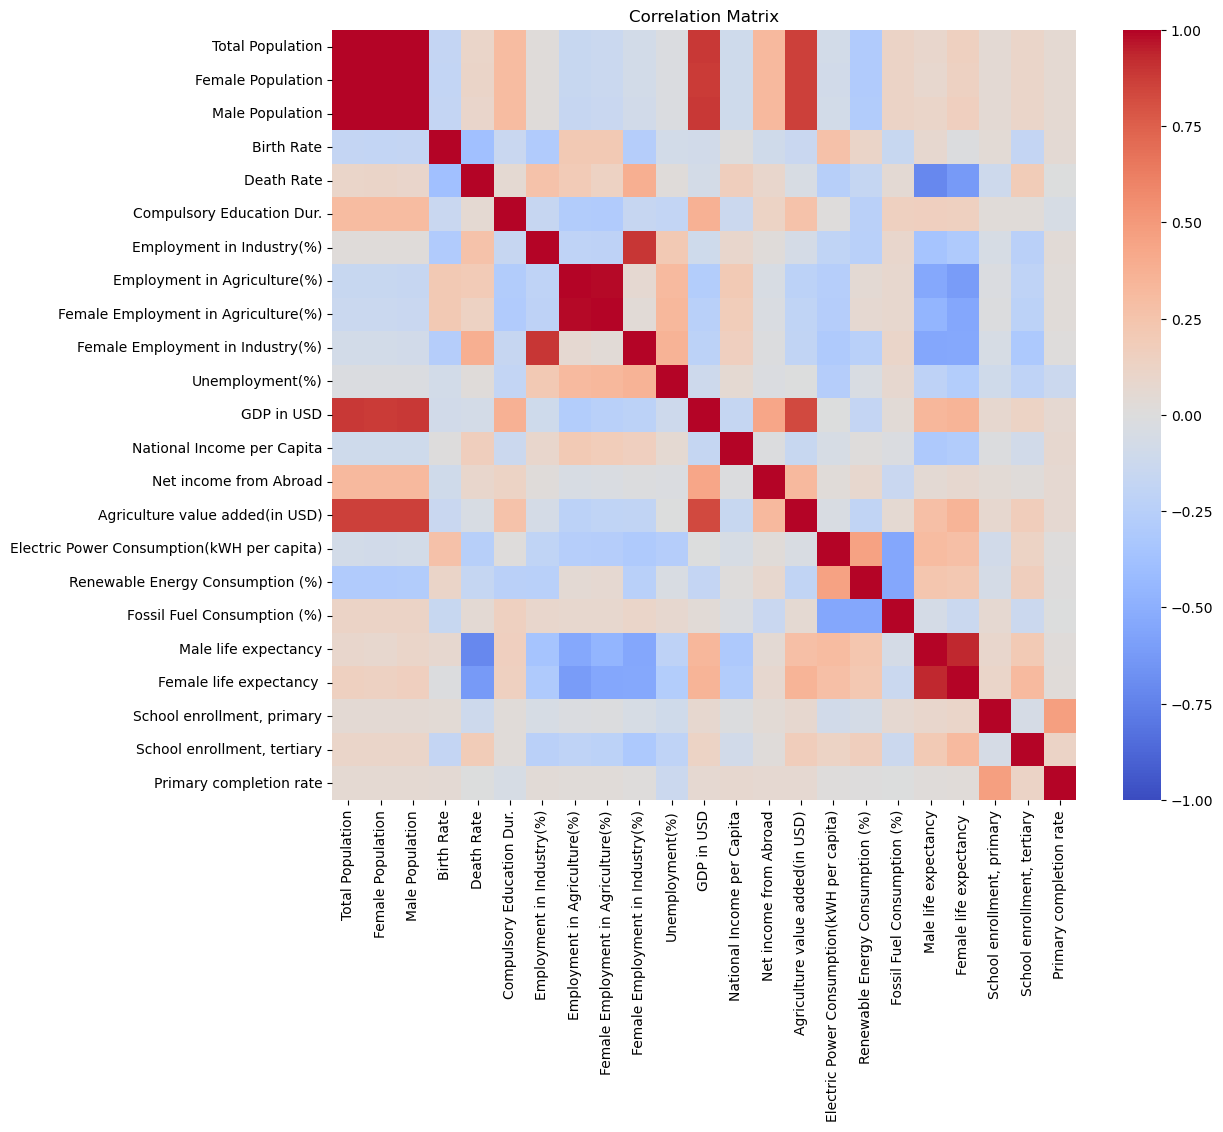

In [51]:
# YOUR CODE HERE
cleaned_numeric_df = cleaned_df.select_dtypes(exclude=['category', 'object'])
correlation_matrix = cleaned_numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, vmin=-1, vmax=1, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


**Question 01**: How does the correlation between features change in the top 10 countries with the LARGEST population?

When we have an answer for this question, we might see how features interaction with each other when the conutry population is large.

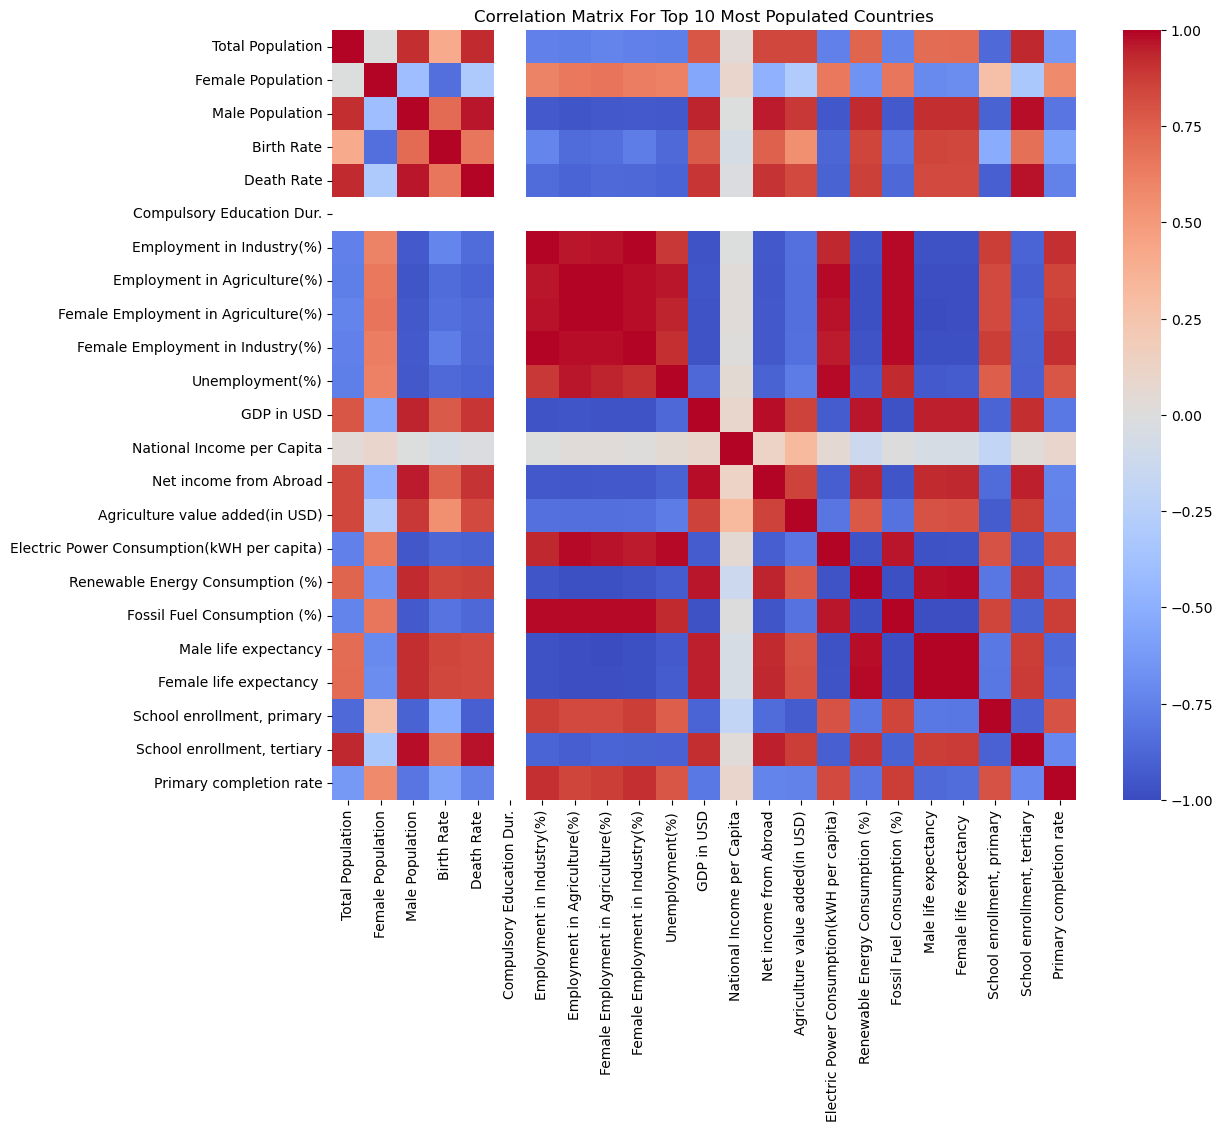

In [52]:
# YOUR CODE HERE
top_10_populated_countries = cleaned_df.nlargest(n=10, columns='Total Population')
numeric_cols_top_10 = top_10_populated_countries.select_dtypes(include=[np.number])
correlation_matrix_top_10 = numeric_cols_top_10.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_top_10, vmin=-1, vmax=1, cmap='coolwarm')
plt.title("Correlation Matrix For Top 10 Most Populated Countries")
plt.show()

YOUR ANSWER HERE

Compared with the dataset including all countries in continent, we can see that:

- In correlation matrix's the top 10 populated countries, the correlations between features may become stronger, especially for variables related to population size and economic factors

- 'National Income per Capita' have weak correlation with most of features. This suggests that other factors such as total GDP, population, energy consumption, or education indicators do not directly impact per capita income in a linear manner.

- "Compulsory Education Dur" has very similar values ​​across the top 10 countries, the difference is so small that calculating the correlation is meaningless, so the result is NaN.

**Question 02**: How does the correlation between features change in the top 10 countries with the SMALLEST population?

When we have an answer for this question, we might see how features interaction with each other when the conutry population is small.

In [53]:
# PRE-PROCESSING IF NEEDED
# YOUR CODE HERE (OPTION) 

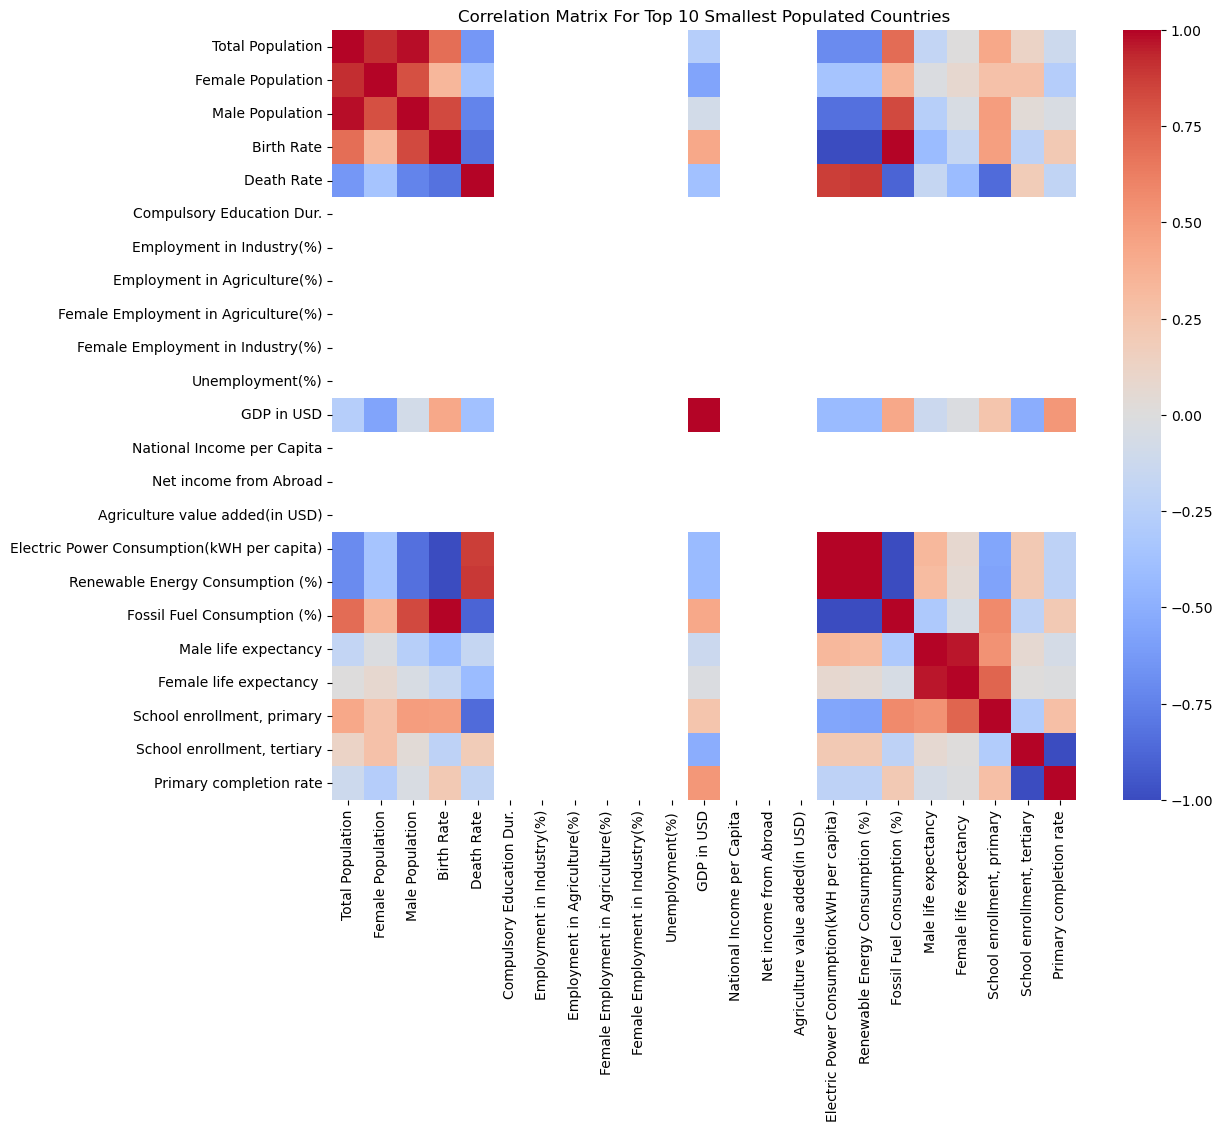

In [54]:
# YOUR CODE HERE
top_10_smallest_populated_countries = cleaned_df.nsmallest(n=10, columns='Total Population')
numeric_cols_top_10_smallest = top_10_smallest_populated_countries.select_dtypes(include=[np.number])
correlation_matrix_top_10_smallest = numeric_cols_top_10_smallest.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_top_10_smallest, vmin=-1, vmax=1, cmap='coolwarm')
plt.title("Correlation Matrix For Top 10 Smallest Populated Countries")
plt.show()

YOUR ANSWER HERE

Compared with the dataset including all countries in continent, we can see that:
- The correlation of top 10 countries with the smallest among features seem to be weaker, we can suggest that in the countries having the small population may not have a strong impact on economic.

- Besides, related-population and related-energy consumption have a stronger negative correlation. This implies that as population of the smallest populated countries increasing, demands of using energy decrease due to resource limitation and insufficient infrashstructure.

## Making a question? (1.25 points)

After exploring the data, we have a better understanding of the data. Now let's see what questions can be answered with this data.

**A possible question is:** What is the population situation of the countries on the continent today?

**Answering this question will** help us to see the current population status and predictions about the future development of the labor force of the countries on the continent are under consideration.

**How we answer this question**: we will consider the Average Birth Rate and Death Rate for countries across all the year.

### Pre-processing

In [55]:
# YOUR CODE HERE (OPTION) 

### Analyzing to get the answer

Step 01: construct Average Birth Rate dataframe for each country.

In [56]:
# Create a new dataframe
avg_birthrate_df = pd.DataFrame()

# YOUR CODE HERE
avg_birthrate_df = cleaned_df.groupby('Country')['Birth Rate'].mean().reset_index()
avg_birthrate_df = avg_birthrate_df.sort_values(by='Birth Rate', ascending=False).reset_index(drop=True)
avg_birthrate_df

,Country,Birth Rate
0,Ireland,14.375000
1,Iceland,14.017857
2,Faroe Islands,13.750000
3,Albania,13.713714
4,Moldova,13.093464
5,Gibraltar,12.433286
6,France,12.378571
7,Norway,12.028571
8,"Macedonia, FYR",11.902847
9,United Kingdom,11.846429


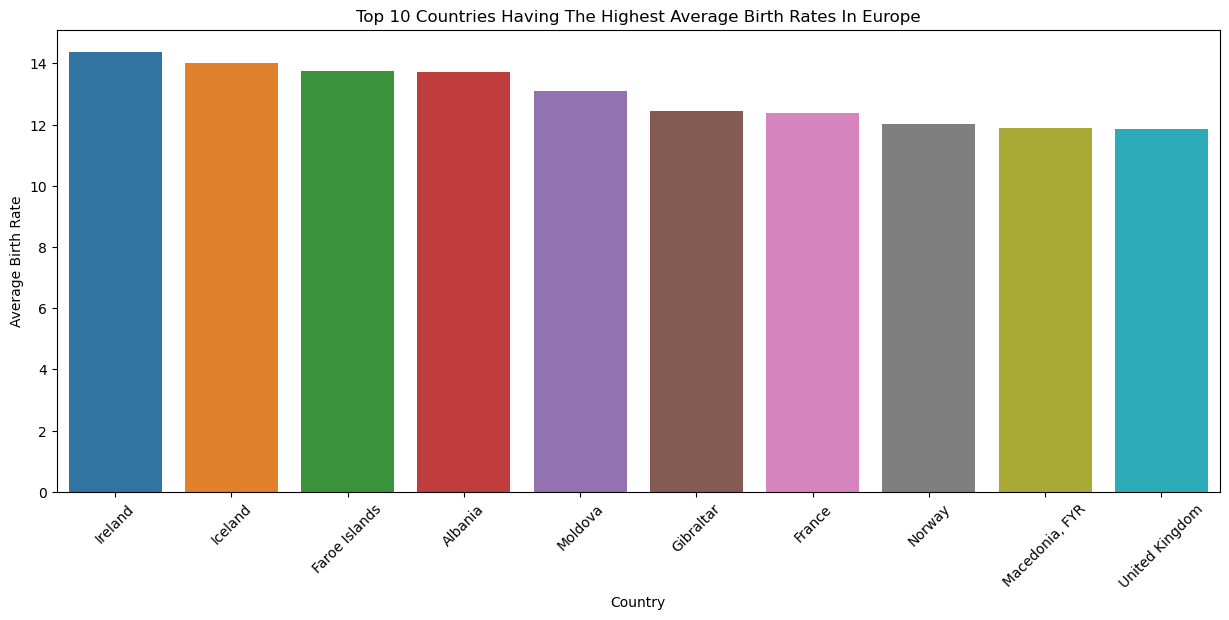

In [57]:
# Plotting for top countries
# YOUR CODE HERE

# Sort average birth rate by decending order
avg_birthrate_df = avg_birthrate_df.sort_values(by='Birth Rate', ascending=False).reset_index(drop=True)
top_birthrate_df = avg_birthrate_df.head(10)

# Plotting
plt.figure(figsize=(15, 6))
sns.barplot(data=top_birthrate_df, x='Country', y='Birth Rate')
plt.title(f'Top 10 Countries Having The Highest Average Birth Rates In {your_continent.capitalize()}')
plt.xlabel('Country')
plt.ylabel('Average Birth Rate')
plt.xticks(rotation=45)
plt.show()

Step 02: construct Average Death Rate dataframe for each country.

In [58]:
# Create a new dataframe
avg_deathrate_df = pd.DataFrame()

# YOUR CODE HERE
avg_deathrate_df = cleaned_df.groupby('Country')['Death Rate'].mean().reset_index()
avg_deathrate_df = avg_deathrate_df.sort_values(by='Death Rate', ascending=False).reset_index(drop=True)
avg_deathrate_df

,Country,Death Rate
0,Ukraine,15.603571
1,Bulgaria,15.157143
2,Latvia,14.596429
3,Belarus,13.895964
4,Hungary,13.457143
5,Moldova,13.414143
6,Lithuania,13.307143
7,Estonia,12.632143
8,Croatia,12.149821
9,Germany,10.767857


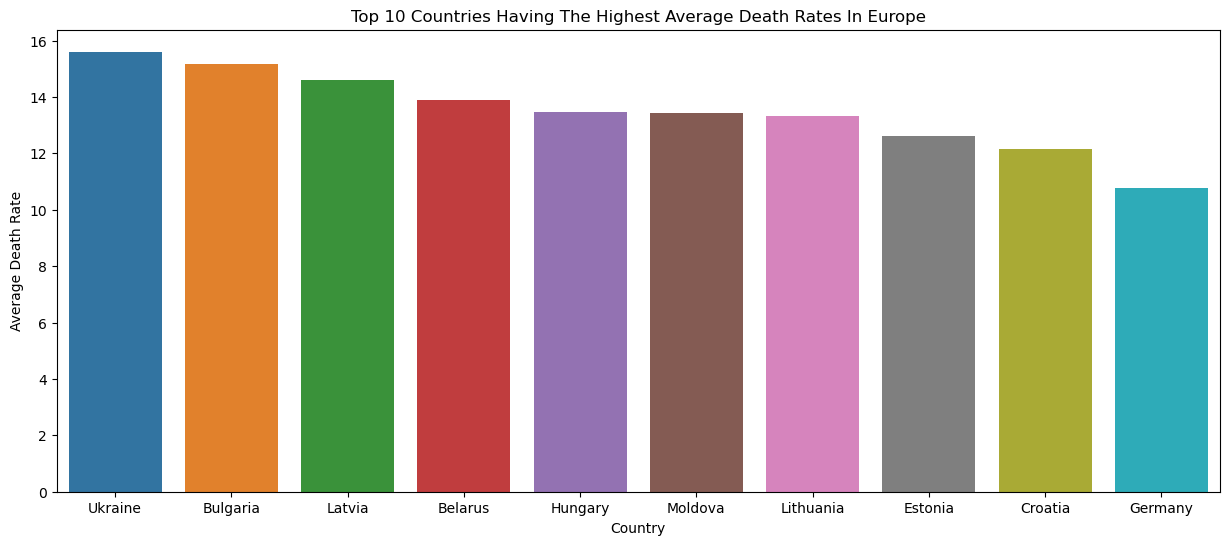

In [59]:
# Plotting for top countries
# YOUR CODE HERE
plt.figure(figsize=(15, 6))
sns.barplot(data=avg_deathrate_df.head(10), x='Country', y='Death Rate')
plt.title(f'Top 10 Countries Having The Highest Average Death Rates In {your_continent.capitalize()}')
plt.xlabel('Country')
plt.ylabel('Average Death Rate')
plt.show()

YOUR ANSWER HERE

- The countries having highest average birth rate in this continent, typically includes Ireland, Iceland, Faroe Islands, ...
- The countries having highest average death rate in this continent, typically includes Ukraine, Bulgaria, Latvia, ...
- Looking at the two charts, we can see that the average death rate of this continent is about 8.55% higher than the average birth rate.
- Looking more closely, countries with the highest average birth rate often have the lowest death rate, and these countries may face the challenge of overpopulation and labor surplus in the future.
- On the contrary, countries with high death rates but low birth rates may need to address their health care and social support systems.

## Making your own question 01? (2 points)

YOUR ANSWER HERE

Questions: How has the GDP per capita changed over the years for the top 5 economies in the dataset?

### Pre-processing

In [60]:
# YOUR CODE HERE (OPTION)
# Ensure 'Year' is of numeric type
cleaned_df['Year'] = pd.to_numeric(cleaned_df['Year'])
cleaned_df['Country'] = cleaned_df['Country'].astype('object')

### Analyzing to get the answer

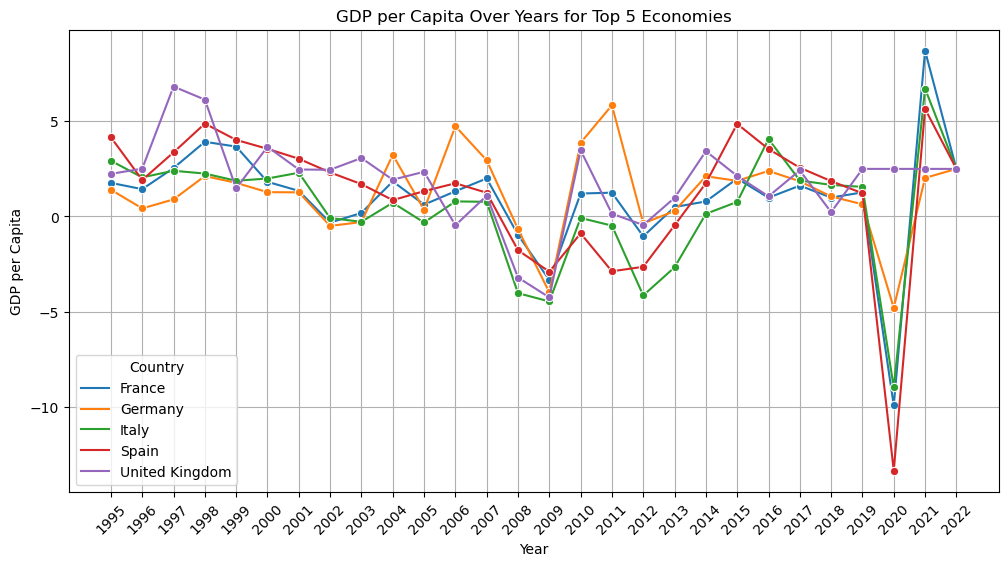

In [61]:
# YOUR CODE HERE
# Calculate average GDP for each country
avg_gdp_df = cleaned_df.groupby('Country')['GDP in USD'].mean().reset_index()

# Get the top 5 countries with the highest average GDP
top_5_economies = avg_gdp_df.nlargest(5, 'GDP in USD')['Country'].tolist()

# Filter data for the top 5 economies
top_economies_df = cleaned_df[cleaned_df['Country'].isin(top_5_economies)]

# Plotting GDP per Capita over the years for each country
plt.figure(figsize=(12, 6))
sns.lineplot(data=top_economies_df, x='Year', y='National Income per Capita', hue='Country', marker='o')
plt.title('GDP per Capita Over Years for Top 5 Economies')
plt.ylabel('GDP per Capita')
plt.xlabel('Year')
plt.legend(title='Country')

plt.xticks(sorted(top_economies_df['Year'].unique()), rotation=45)
plt.grid()

plt.show()



### Your conclusion

YOUR ANSWER HERE


## Making your own question 02 (2 points)

YOUR ANSWER HERE
- The top 5 economies include France, Germany, Italy, Spain, and the UK.
- The GDP per capita of the 5 countries started the period 1995-1996 without much difference. 
- By 1997, the UK had a GDP per capita that grew more rapidly than the remaining economies.
- From then until 2009, all economies tended to decline significantly to negative levels. After that period, the GDP per capita gradually increased again.
- Around the time of the COVID-19 pandemic in 2020, the GDP per capita fell to its lowest level in the period 1995-2022.
- After 2020, all 5 economies had a GDP per capita that tended to grow significantly.

### Pre-processing

In [62]:
# YOUR CODE HERE (OPTION) 

### Analyzing to get the answer

Correlation between School Enrollment in Primary and National Income per Capita: -0.01
Correlation between School Enrollment in Tertiary and National Income per Capita: -0.09


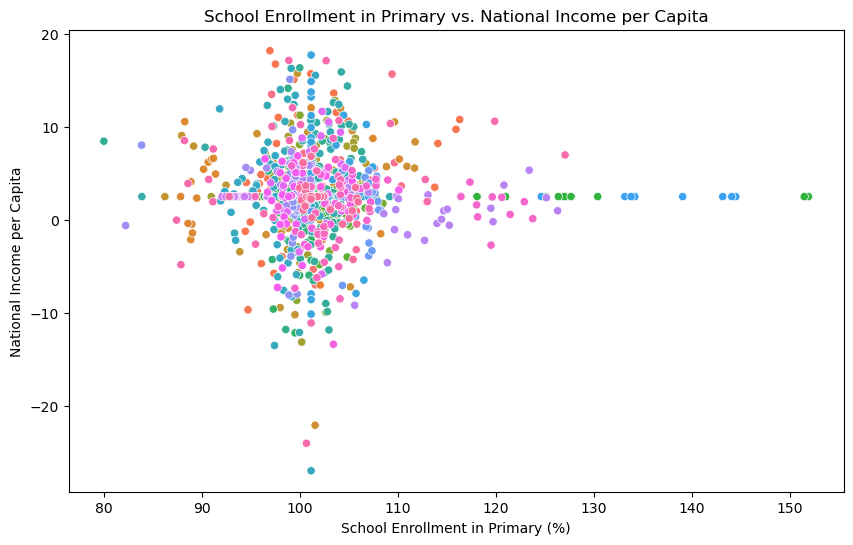

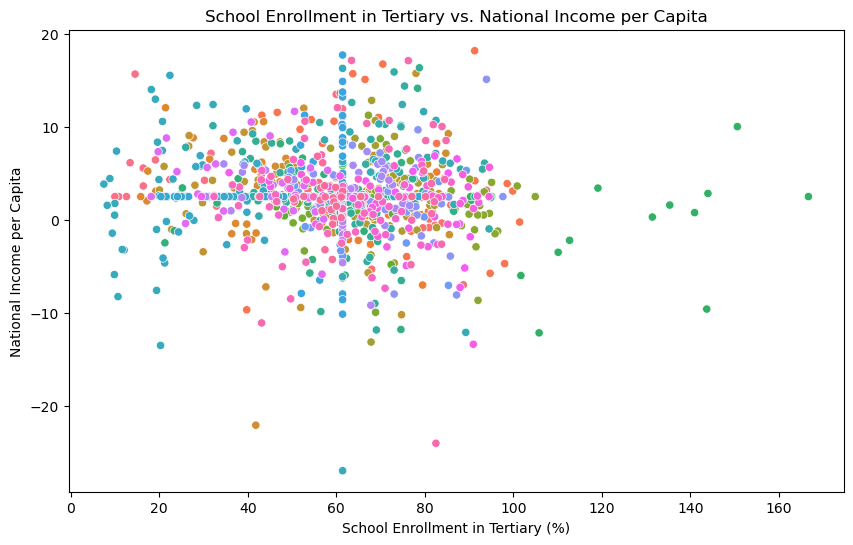

In [63]:
# YOUR CODE HERE
# Calculate correlation coefficients
corr_primary = cleaned_df['School enrollment, primary'].corr(cleaned_df['National Income per Capita'])
corr_tertiary = cleaned_df['School enrollment, tertiary'].corr(cleaned_df['National Income per Capita'])

print(f"Correlation between School Enrollment in Primary and National Income per Capita: {corr_primary:.2f}")
print(f"Correlation between School Enrollment in Tertiary and National Income per Capita: {corr_tertiary:.2f}")


plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleaned_df, x='School enrollment, primary', y='National Income per Capita', hue='Country', legend=False)
plt.title('School Enrollment in Primary vs. National Income per Capita')
plt.xlabel('School Enrollment in Primary (%)')
plt.ylabel('National Income per Capita')
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleaned_df, x='School enrollment, tertiary', y='National Income per Capita', hue='Country', legend=False)
plt.title('School Enrollment in Tertiary vs. National Income per Capita')
plt.xlabel('School Enrollment in Tertiary (%)')
plt.ylabel('National Income per Capita')
plt.show()


### Your conclusion

YOUR ANSWER HERE

Correlation Coefficient of -0.01 (Primary Enrollment):
- This correlation is effectively zero, indicating no linear relationship between primary school enrollment rates and national income per capita.

Correlation Coefficient of -0.09 (Tertiary Enrollment):
- This is a very weak negative correlation, suggesting a slight tendency for countries with higher tertiary enrollment rates to have lower national income per capita. However, the relationship is so weak that it is practically negligible.